In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("./dc.csv")

In [18]:
df = df[["N", "initial", "small_rho", "high_rho" ,"small_gamma", "high_gamma"]]

In [19]:
df["small_rho_ratio"] = df["small_rho"]/df["initial"]
df["high_rho_ratio"] = df["high_rho"]/df["initial"]
df["small_gamma_ratio"] = df["small_gamma"]/df["initial"]
df["high_gamma_ratio"] = df["high_gamma"]/df["initial"]

In [20]:
df

,N,initial,small_rho,high_rho,small_gamma,high_gamma,small_rho_ratio,high_rho_ratio,small_gamma_ratio,high_gamma_ratio
0,50,1487.49,1475,1828.63,79.1020,1828.63,0.991603,1.229339,0.053178,1.229339
1,50,1321.52,1315,1701.16,104.7230,1701.16,0.995066,1.287275,0.079244,1.287275
2,50,1663.33,1652,2059.49,81.2062,2059.49,0.993188,1.238173,0.048821,1.238173
3,50,1625.25,1614,2047.54,114.1490,2047.54,0.993078,1.259831,0.070235,1.259831
4,50,1378.40,1360,1754.61,106.3580,1754.61,0.986651,1.272932,0.077160,1.272932
5,50,1530.28,1508,1849.51,90.1286,1849.51,0.985441,1.208609,0.058897,1.208609
6,50,1450.44,1425,1796.26,171.2300,1796.26,0.982460,1.238424,0.118054,1.238424
7,50,1558.69,1533,1920.37,113.8660,1920.37,0.983518,1.232041,0.073052,1.232041
8,50,1457.51,1443,1853.84,154.1480,1853.84,0.990045,1.271923,0.105761,1.271923
9,50,1574.37,1557,2001.58,103.9180,2001.58,0.988967,1.271353,0.066006,1.271353


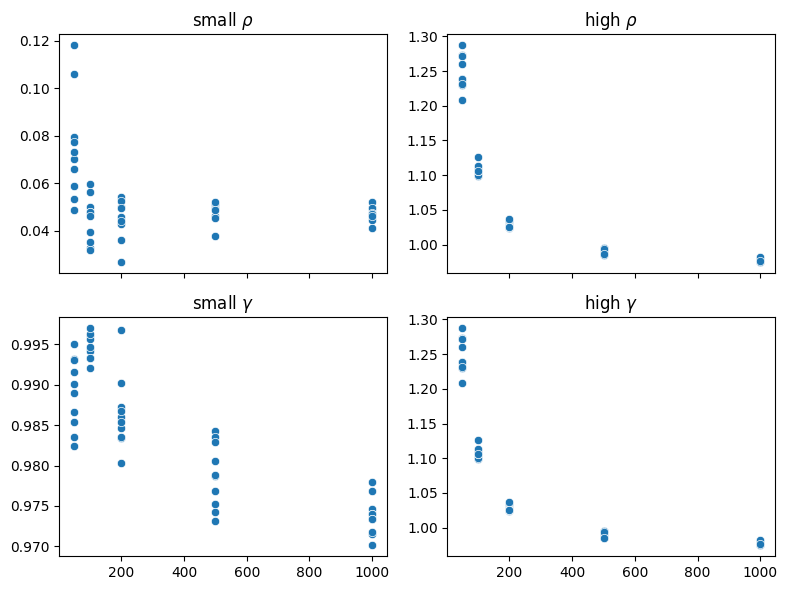

In [21]:
fig, axes = plt.subplots(2,2, sharex=True, figsize=(8, 6))

sns.scatterplot(df, x = "N", y = "small_gamma_ratio", ax = axes[0][0])
sns.scatterplot(df, x = "N", y = "high_gamma_ratio", ax = axes[0][1])
sns.scatterplot(df, x = "N", y = "small_rho_ratio", ax = axes[1][0])
sns.scatterplot(df, x = "N", y = "high_rho_ratio", ax = axes[1][1])

axes[0][0].set(xlabel = "", ylabel = "", title = r"small $\rho$")
axes[0][1].set(xlabel = "", ylabel = "", title = r"high $\rho$")
axes[1][0].set(xlabel = "", ylabel = "", title = r"small $\gamma$")
axes[1][1].set(xlabel = "", ylabel = "", title = r"high $\gamma$")

plt.tight_layout()
fig.savefig("dc.png", dpi = 200)

In [40]:
#VND

df = pd.read_csv("./vnd.csv")

In [41]:

df = df[["N", "permutation", "objective"]]

In [42]:
df["permutation"] = df["permutation"].apply(
    lambda x: f"{x}0" if x < 100 else str(x)
)


In [43]:
df

,N,permutation,objective
0,50,120,967.759
1,50,210,903.970
2,50,102,969.970
3,50,120,925.970
4,50,201,1019.970
...,...,...,...
235,500,210,27639.100
236,500,102,26008.600
237,500,120,24884.600
238,500,201,27408.900


In [45]:
df[(df["N"]==50)&(df["permutation"]=="120")]

,N,permutation,objective
0,50,120,967.759
3,50,120,925.970
6,50,120,769.320
9,50,120,885.766
12,50,120,826.530
15,50,120,976.530
18,50,120,968.135
21,50,120,947.135
24,50,120,999.905
27,50,120,922.717


In [48]:
df

,N,permutation,objective
0,50,120,967.759
1,50,210,903.970
2,50,102,969.970
3,50,120,925.970
4,50,201,1019.970
...,...,...,...
235,500,210,27639.100
236,500,102,26008.600
237,500,120,24884.600
238,500,201,27408.900


In [46]:
new = df.groupby(by = ["N", "permutation"]).mean().reset_index()

In [49]:
# new["normalised"] = new["objective"]/new.transform(new.groupby(by = "N").mean())

new["normalised"] = new["objective"] / new.groupby("N")["objective"].transform("mean")


In [50]:
new

,N,permutation,objective,normalised
0,50,102,1073.0490,1.097130
1,50,120,940.5124,0.961619
2,50,201,933.9481,0.954907
3,50,210,964.6953,0.986344
4,100,102,2342.7110,0.977805
5,100,120,2362.0560,0.985880
6,100,201,2418.3850,1.009390
7,100,210,2460.3960,1.026925
8,200,102,6515.4590,0.981503
9,200,120,6522.6425,0.982586


[Text(0.5, 1.0, 'Effect of neighborhood order in VND'), Text(0, 0.5, '')]

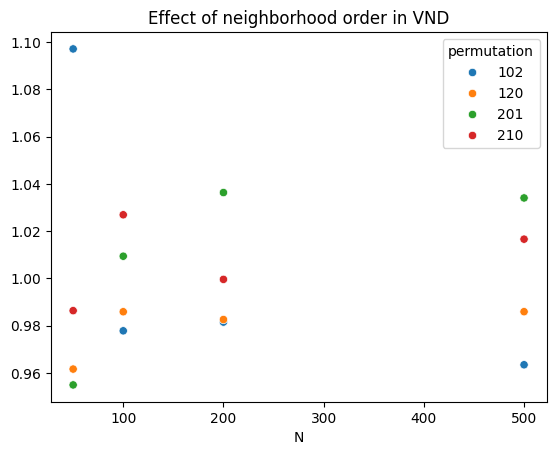

In [55]:
fig, ax = plt.subplots(1,1)

sns.scatterplot(new, x = "N", y = "normalised", hue = "permutation")

ax.set(title = "Effect of neighborhood order in VND", ylabel ="")

In [57]:
fig.savefig("vnd_neigh_order.png", dpi = 200)

In [58]:
# LAMBDA

In [60]:
df = pd.read_csv("lamda_tuning.csv")

In [62]:
df = df[["N", "lamda", "objective"]]

In [65]:
new = df.groupby(by = ["N", "lamda"]).mean().reset_index()

In [67]:
new["normalised"] = new["objective"]/new.groupby("N")["objective"].transform("mean")

In [68]:
new

,N,lamda,objective,normalised
0,50,0.01,3027.061333,1.325847
1,50,0.03,2759.026333,1.208448
2,50,0.05,2424.804333,1.062059
3,50,0.07,2250.273333,0.985615
4,50,0.10,2004.830667,0.878112
5,50,0.15,1807.149000,0.791528
6,50,0.20,1708.665667,0.748392
7,100,0.01,8186.884667,1.431755
8,100,0.03,7001.398333,1.224432
9,100,0.05,6043.529000,1.056916


[Text(0.5, 1.0, 'Effect of $\\lambda$ in Randomised Solution'),
 Text(0, 0.5, '')]

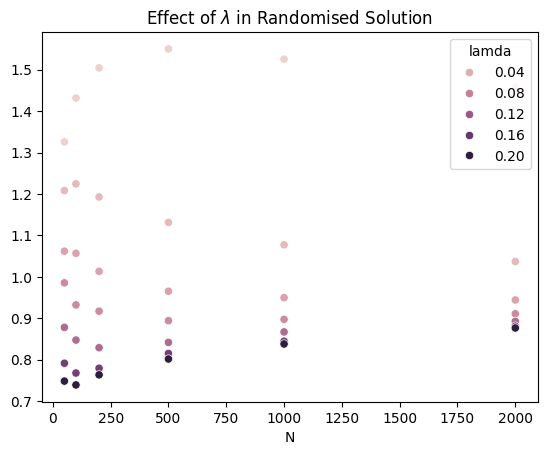

In [72]:
fig, ax = plt.subplots(1,1)

sns.scatterplot(new, x = "N", y = "normalised", hue = "lamda", ax = ax)


ax.set(title = r"Effect of $\lambda$ in Randomised Solution", ylabel ="")

In [73]:
fig.savefig("rc.png", dpi = 200)